# 2D Soft Body Dynamics: FEM Volumetric Forces

This tutorial extends the implicit solver with **Finite Element Method (FEM)** forces for **area/volume preservation**.

**Learning Goals:**
1. Understand why springs fail to preserve volume
2. Learn the Finite Element Method for continuum mechanics
3. Implement Neo-Hookean material model in 2D
4. Build FEM stiffness matrix for implicit integration

**Prerequisites:** Complete [02_implicit.ipynb](02_implicit.ipynb) first!

---
## 1. Why Springs Fail: The Volume Problem

Springs only resist **length** changes along edges. They cannot resist:
- **Area changes** (2D) or **volume changes** (3D)
- **Shearing** deformations

**Solution:** Use triangular elements that track the full **deformation gradient**.

---
## 2. Finite Element Method Basics

### Deformation Gradient
$$\mathbf{F} = \mathbf{D}_s \mathbf{D}_m^{-1}$$

### Key Invariants
- $I_C = \|\mathbf{F}\|^2$ = squared Frobenius norm (measures stretch)
- $J = \det(\mathbf{F})$ = area ratio (current/rest)

### Neo-Hookean Energy
$$\Psi = \frac{\mu}{2}(I_C - 2) + \frac{\lambda}{2}(J - 1)^2$$

---
## 3. Implementation

In [1]:
# Step 1: Imports
import os
import sys

# Add the tutorial/Warp directory to path for imports
_warp_tutorial_dir = os.path.join(os.getcwd(), 'tutorial', 'Warp')
if os.path.exists(_warp_tutorial_dir) and _warp_tutorial_dir not in sys.path:
    sys.path.insert(0, _warp_tutorial_dir)
elif os.path.exists('utils.py') and os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import os
import sys
# Ensure we can import from the notebook's directory

import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve()))  # Add notebook directory to path

import numpy as np
import warp as wp
from warp.optim.linear import bicgstab, preconditioner
from warp.sparse import bsr_zeros, bsr_set_from_triplets
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import Image
import time

# Import shared utilities from previous tutorials
from utils import (
    State, Model, 
    eval_spring_2d, apply_boundary_2d, build_spring_matrix_2d,
    update_state_2d, eval_gravity_2d,
    create_spring_colormap, create_fem_colormap
)

wp.init()
print(f'Warp {wp.__version__} on {wp.get_device()}')

Warp 1.11.0.dev20251123 initialized:
   Git commit: 8b8f0b85ca54c0026574f834764e26615056aef6
   CUDA Toolkit 12.8, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA L40S" (44 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.11.0.dev20251123
Warp 1.11.0.dev20251123 on cuda:0


In [2]:
# Step 2: Spring Force Kernel (imported from utils.py)
# The eval_spring_2d kernel was imported above from utils.py
# See 01_explicit.ipynb for the full implementation details.
print('Spring kernel imported from utils.py')

Spring kernel imported from utils.py


In [3]:
# Step 3: FEM Force Kernel (from 11_warp_2d_soft_robot.ipynb)
@wp.kernel
def eval_fem_2d(
    x: wp.array(dtype=wp.vec2), v: wp.array(dtype=wp.vec2),
    indices: wp.array(dtype=int), pose: wp.array(dtype=wp.mat22),
    materials: wp.array(dtype=wp.vec3), f: wp.array(dtype=wp.vec2),
    tri_strains: wp.array(dtype=float),
):
    tid = wp.tid()
    i = indices[tid * 3 + 0]
    j = indices[tid * 3 + 1]
    k = indices[tid * 3 + 2]
    
    mat = materials[tid]
    k_mu = mat[0]
    k_lambda = mat[1]
    k_damp = mat[2]
    
    x0, x1, x2 = x[i], x[j], x[k]
    v0, v1, v2 = v[i], v[j], v[k]
    x10, x20 = x1 - x0, x2 - x0
    v10, v20 = v1 - v0, v2 - v0
    
    Ds = wp.mat22(x10[0], x20[0], x10[1], x20[1])
    Dm = pose[tid]
    det_Dm = wp.determinant(Dm)
    rest_area = 0.5 / wp.abs(det_Dm)
    
    k_mu = k_mu * rest_area
    k_lambda = k_lambda * rest_area
    k_damp = k_damp * rest_area
    
    F = Ds * Dm
    dFdt = wp.mat22(v10[0], v20[0], v10[1], v20[1]) * Dm
    
    col1 = wp.vec2(F[0, 0], F[1, 0])
    col2 = wp.vec2(F[0, 1], F[1, 1])
    Ic = wp.max(wp.dot(col1, col1) + wp.dot(col2, col2), 0.01)
    
    P = F * k_mu * (Ic - 2.0) / Ic + dFdt * k_damp
    H = P * wp.transpose(Dm)
    f1 = wp.vec2(H[0, 0], H[1, 0])
    f2 = wp.vec2(H[0, 1], H[1, 1])
    
    J = wp.determinant(F)
    dJdx1 = wp.vec2(x20[1], -x20[0]) * det_Dm
    dJdx2 = wp.vec2(-x10[1], x10[0]) * det_Dm
    
    f_vol = (J - 1.0) * k_lambda
    f_damp = (wp.dot(dJdx1, v1) + wp.dot(dJdx2, v2)) * k_damp
    f_total = f_vol + f_damp
    
    f1 = f1 + dJdx1 * f_total
    f2 = f2 + dJdx2 * f_total
    f0 = -(f1 + f2)
    
    tri_strains[tid] = J - 1.0
    
    wp.atomic_sub(f, i, f0)
    wp.atomic_sub(f, j, f1)
    wp.atomic_sub(f, k, f2)
print('FEM kernel defined')

FEM kernel defined


In [4]:
# Step 4: Stiffness Matrix Kernels
# build_spring_matrix_2d, update_state_2d, eval_gravity_2d, apply_boundary_2d 
# are imported from utils.py (see 02_implicit.ipynb for details)

# NEW: FEM stiffness matrix kernel (introduced in this tutorial)
@wp.kernel
def build_fem_matrix_2d(
    x: wp.array(dtype=wp.vec2), tri_indices: wp.array(dtype=int),
    tri_poses: wp.array(dtype=wp.mat22), tri_materials: wp.array(dtype=wp.vec3),
    fem_rows: wp.array(dtype=wp.int32), fem_cols: wp.array(dtype=wp.int32),
    fem_values: wp.array(dtype=wp.mat22f), dt: float
):
    tid = wp.tid()
    i = tri_indices[tid * 3 + 0]
    j = tri_indices[tid * 3 + 1]
    k = tri_indices[tid * 3 + 2]
    mat = tri_materials[tid]
    k_mu = mat[0]
    k_lambda = mat[1]
    
    x10 = x[j] - x[i]
    x20 = x[k] - x[i]
    Ds = wp.mat22(x10[0], x20[0], x10[1], x20[1])
    Dm = tri_poses[tid]
    det_Dm = wp.determinant(Dm)
    area = 0.5 / wp.abs(det_Dm)
    k_mu = k_mu * area
    k_lambda = k_lambda * area
    
    F = Ds * Dm
    col1 = wp.vec2(F[0, 0], F[1, 0])
    col2 = wp.vec2(F[0, 1], F[1, 1])
    Ic = wp.max(wp.dot(col1, col1) + wp.dot(col2, col2), 0.1)
    J = wp.determinant(F)
    K_eff = k_mu * (1.0 + 4.0 / Ic) + k_lambda * (1.0 + 2.0 * wp.abs(J - 1.0))
    K_sc = dt * dt * K_eff
    
    b1 = wp.vec2(Dm[0, 0], Dm[1, 0])
    b2 = wp.vec2(Dm[0, 1], Dm[1, 1])
    b0 = -(b1 + b2)
    
    base = tid * 9
    fem_rows[base + 0] = i
    fem_cols[base + 0] = i
    fem_values[base + 0] = wp.mat22f(K_sc * b0[0] * b0[0], K_sc * b0[0] * b0[1], K_sc * b0[1] * b0[0], K_sc * b0[1] * b0[1])
    fem_rows[base + 1] = i
    fem_cols[base + 1] = j
    fem_values[base + 1] = wp.mat22f(K_sc * b0[0] * b1[0], K_sc * b0[0] * b1[1], K_sc * b0[1] * b1[0], K_sc * b0[1] * b1[1])
    fem_rows[base + 2] = i
    fem_cols[base + 2] = k
    fem_values[base + 2] = wp.mat22f(K_sc * b0[0] * b2[0], K_sc * b0[0] * b2[1], K_sc * b0[1] * b2[0], K_sc * b0[1] * b2[1])
    fem_rows[base + 3] = j
    fem_cols[base + 3] = i
    fem_values[base + 3] = wp.mat22f(K_sc * b1[0] * b0[0], K_sc * b1[0] * b0[1], K_sc * b1[1] * b0[0], K_sc * b1[1] * b0[1])
    fem_rows[base + 4] = j
    fem_cols[base + 4] = j
    fem_values[base + 4] = wp.mat22f(K_sc * b1[0] * b1[0], K_sc * b1[0] * b1[1], K_sc * b1[1] * b1[0], K_sc * b1[1] * b1[1])
    fem_rows[base + 5] = j
    fem_cols[base + 5] = k
    fem_values[base + 5] = wp.mat22f(K_sc * b1[0] * b2[0], K_sc * b1[0] * b2[1], K_sc * b1[1] * b2[0], K_sc * b1[1] * b2[1])
    fem_rows[base + 6] = k
    fem_cols[base + 6] = i
    fem_values[base + 6] = wp.mat22f(K_sc * b2[0] * b0[0], K_sc * b2[0] * b0[1], K_sc * b2[1] * b0[0], K_sc * b2[1] * b0[1])
    fem_rows[base + 7] = k
    fem_cols[base + 7] = j
    fem_values[base + 7] = wp.mat22f(K_sc * b2[0] * b1[0], K_sc * b2[0] * b1[1], K_sc * b2[1] * b1[0], K_sc * b2[1] * b1[1])
    fem_rows[base + 8] = k
    fem_cols[base + 8] = k
    fem_values[base + 8] = wp.mat22f(K_sc * b2[0] * b2[0], K_sc * b2[0] * b2[1], K_sc * b2[1] * b2[0], K_sc * b2[1] * b2[1])

print('FEM stiffness kernel defined (others imported from utils.py)')

FEM stiffness kernel defined (others imported from utils.py)


In [5]:
# Step 5: State and Model (imported from utils.py)
# State and Model classes are imported from utils.py
# Model.from_circle() supports FEM with use_fem=True parameter
# See previous tutorials for the full implementation details.
print('State and Model imported from utils.py (use_fem=True for FEM triangles)')

# Note: The Model class in utils.py has a from_circle() factory method that supports:
#   - use_fem=True: Creates FEM triangles in addition to springs
#   - fem_mu, fem_lambda, fem_damping: FEM material properties

# For this tutorial, we use a slightly customized version to match the original:
class ModelFEM:
    def __init__(self, device='cuda'):
        self.device = wp.get_device(device)
        self.particle_q = None
        self.particle_qd = None
        self.particle_count = 0
        self.spring_indices = None
        self.spring_rest_length = None
        self.spring_stiffness = None
        self.spring_damping = None
        self.spring_count = 0
        self.spring_strains = None
        self.tri_indices = None
        self.tri_count = 0
        self.tri_materials = None
        self.tri_poses = None
        self.tri_strains = None
        self.gravity = None
        self.boxsize = 3.0
    
    def state(self):
        s = State()
        s.particle_q = wp.clone(self.particle_q)
        s.particle_qd = wp.clone(self.particle_qd)
        s.particle_f = wp.zeros(self.particle_count, dtype=wp.vec2, device=self.device)
        return s
    
    def set_gravity(self, g):
        if self.gravity is None:
            self.gravity = wp.zeros(1, dtype=wp.vec2, device=self.device)
        self.gravity.assign([wp.vec2(g[0], g[1])])
    
    @classmethod
    def from_circle(cls, radius=0.5, num_boundary=20, num_rings=3, device='cuda', boxsize=3.0, center=None):
        model = cls(device=device)
        model.boxsize = boxsize
        if center is None:
            center = (boxsize / 2.0, boxsize / 2.0)
        cx, cy = center
        
        all_pts = []
        angles = np.linspace(0, 2 * np.pi, num_boundary, endpoint=False)
        all_pts.append(np.c_[radius * np.cos(angles), radius * np.sin(angles)])
        for ring in range(1, num_rings + 1):
            r = radius * (num_rings - ring + 1) / (num_rings + 1)
            n = max(8, int(num_boundary * r / radius))
            a = np.linspace(0, 2 * np.pi, n, endpoint=False) + np.pi / num_boundary * ring
            all_pts.append(np.c_[r * np.cos(a), r * np.sin(a)])
        all_pts.append([[0.0, 0.0]])
        pts_norm = np.vstack(all_pts)
        tri = Delaunay(pts_norm)
        
        valid_tris = []
        for simplex in tri.simplices:
            cent = np.mean(pts_norm[simplex], axis=0)
            if np.linalg.norm(cent) <= radius * 1.01:
                p0, p1, p2 = pts_norm[simplex]
                cross = (p1 - p0)[0] * (p2 - p0)[1] - (p1 - p0)[1] * (p2 - p0)[0]
                if abs(cross) >= 1e-8:
                    if cross < 0:
                        simplex = [simplex[0], simplex[2], simplex[1]]
                    valid_tris.append(simplex)
        
        pts = pts_norm * radius * boxsize / 2.0
        pts[:, 0] += cx
        pts[:, 1] += cy
        n = len(pts)
        model.particle_count = n
        model.particle_q = wp.array(pts.astype(np.float32), dtype=wp.vec2, device=device)
        model.particle_qd = wp.zeros(n, dtype=wp.vec2, device=device)
        
        edges = set()
        for t in valid_tris:
            for e in [(t[0], t[1]), (t[1], t[2]), (t[2], t[0])]:
                edges.add(tuple(sorted(e)))
        spring_idx, spring_len = [], []
        for v0, v1 in edges:
            spring_idx.extend([v0, v1])
            spring_len.append(np.linalg.norm(pts[v1] - pts[v0]))
        model.spring_count = len(edges)
        model.spring_indices = wp.array(np.array(spring_idx, dtype=np.int32), dtype=int, device=device)
        model.spring_rest_length = wp.array(np.array(spring_len, dtype=np.float32), dtype=float, device=device)
        model.spring_stiffness = wp.full(model.spring_count, 40.0, dtype=float, device=device)
        model.spring_damping = wp.full(model.spring_count, 0.5, dtype=float, device=device)
        model.spring_strains = wp.zeros(model.spring_count, dtype=float, device=device)
        
        tri_idx = []
        for t in valid_tris:
            tri_idx.extend(t)
        model.tri_count = len(valid_tris)
        model.tri_indices = wp.array(np.array(tri_idx, dtype=np.int32), dtype=int, device=device)
        model.tri_strains = wp.zeros(model.tri_count, dtype=float, device=device)
        
        poses = []
        for t in valid_tris:
            p0, p1, p2 = pts[t[0]], pts[t[1]], pts[t[2]]
            e1, e2 = p1 - p0, p2 - p0
            Dm = np.array([[e1[0], e2[0]], [e1[1], e2[1]]], dtype=np.float32)
            poses.append(np.linalg.inv(Dm).flatten())
        model.tri_poses = wp.array(np.array(poses, dtype=np.float32), dtype=wp.mat22, device=device)
        
        # Material parameters from E and nu
        E, nu = 50.0, 0.3
        k_mu = E / (2 * (1 + nu))
        k_lambda = E * nu / (1 - nu * nu)
        model.tri_materials = wp.full(model.tri_count, wp.vec3(k_mu, k_lambda, 2.0), dtype=wp.vec3, device=device)
        
        model.set_gravity((0.0, -0.1))
        print(f'Circle: {n} particles, {model.spring_count} springs, {model.tri_count} triangles')
        return model

print('State and Model defined')

State and Model imported from utils.py (use_fem=True for FEM triangles)
State and Model defined


In [6]:
# Step 6: Implicit FEM Solver (from 11_warp_2d_soft_robot.ipynb)
class SolverImplicitFEM:
    def __init__(self, model, mass=1.0):
        self.model = model
        self.mass = mass
        self.Minv = 1.0 / mass
        
        spr_blk = model.spring_count * 4
        fem_blk = model.tri_count * 9
        total = spr_blk + fem_blk
        
        self.spr_rows = wp.zeros(spr_blk, dtype=wp.int32, device=model.device)
        self.spr_cols = wp.zeros(spr_blk, dtype=wp.int32, device=model.device)
        self.spr_vals = wp.zeros(spr_blk, dtype=wp.mat22f, device=model.device)
        self.fem_rows = wp.zeros(fem_blk, dtype=wp.int32, device=model.device)
        self.fem_cols = wp.zeros(fem_blk, dtype=wp.int32, device=model.device)
        self.fem_vals = wp.zeros(fem_blk, dtype=wp.mat22f, device=model.device)
        self.bsr_rows = wp.zeros(total, dtype=wp.int32, device=model.device)
        self.bsr_cols = wp.zeros(total, dtype=wp.int32, device=model.device)
        self.bsr_vals = wp.zeros(total, dtype=wp.mat22f, device=model.device)
        
        self.A = bsr_zeros(model.particle_count, model.particle_count, wp.mat22f, device=model.device)
        self.M = None
        self.dv = wp.zeros(model.particle_count, dtype=wp.vec2, device=model.device)
    
    def build_matrix(self, state, dt):
        m = self.model
        wp.launch(build_spring_matrix_2d, dim=m.spring_count, inputs=[
            self.spr_rows, self.spr_cols, self.spr_vals, m.spring_indices,
            m.spring_stiffness, m.spring_damping, wp.float32(dt), self.mass, self.Minv], device=m.device)
        
        wp.launch(build_fem_matrix_2d, dim=m.tri_count, inputs=[
            state.particle_q, m.tri_indices, m.tri_poses, m.tri_materials,
            self.fem_rows, self.fem_cols, self.fem_vals, wp.float32(dt)], device=m.device)
        
        sn, fn = m.spring_count * 4, m.tri_count * 9
        wp.copy(self.bsr_rows, self.spr_rows, count=sn)
        wp.copy(self.bsr_cols, self.spr_cols, count=sn)
        wp.copy(self.bsr_vals, self.spr_vals, count=sn)
        wp.copy(self.bsr_rows, self.fem_rows, dest_offset=sn, count=fn)
        wp.copy(self.bsr_cols, self.fem_cols, dest_offset=sn, count=fn)
        wp.copy(self.bsr_vals, self.fem_vals, dest_offset=sn, count=fn)
        
        bsr_set_from_triplets(self.A, self.bsr_rows, self.bsr_cols, self.bsr_vals, prune_numerical_zeros=True)
        self.M = preconditioner(self.A, ptype='diag')
    
    def step(self, state_in, state_out, dt):
        m = self.model
        self.build_matrix(state_in, dt)
        
        spr_f = wp.zeros(m.particle_count, dtype=wp.vec2, device=m.device)
        wp.launch(eval_spring_2d, dim=m.spring_count, inputs=[
            state_in.particle_q, state_in.particle_qd, m.spring_indices,
            m.spring_rest_length, m.spring_stiffness, m.spring_damping,
            spr_f, m.spring_strains], device=m.device)
        
        fem_f = wp.zeros(m.particle_count, dtype=wp.vec2, device=m.device)
        wp.launch(eval_fem_2d, dim=m.tri_count, inputs=[
            state_in.particle_q, state_in.particle_qd, m.tri_indices,
            m.tri_poses, m.tri_materials, fem_f, m.tri_strains], device=m.device)
        
        grav_f = wp.zeros(m.particle_count, dtype=wp.vec2, device=m.device)
        g = m.gravity.numpy()[0]
        wp.launch(eval_gravity_2d, dim=m.particle_count,
                  inputs=[wp.vec2(g[0] * self.mass, g[1] * self.mass)], outputs=[grav_f], device=m.device)
        
        state_in.particle_f = dt * (spr_f + fem_f + grav_f)
        bicgstab(self.A, state_in.particle_f, self.dv, tol=1e-3, maxiter=10, M=self.M, use_cuda_graph=True)
        
        wp.launch(update_state_2d, dim=m.particle_count, inputs=[
            self.dv, dt, state_in.particle_q, state_in.particle_qd,
            state_out.particle_q, state_out.particle_qd], device=m.device)
        
        wp.launch(apply_boundary_2d, dim=m.particle_count, inputs=[
            state_out.particle_q, state_out.particle_qd, m.boxsize], device=m.device)
        return state_out

print('Solver defined')

Solver defined


---
## 4. Simulation

In [7]:
# Run Simulation
# SAME body SIZE as all tutorials (1-3, 5): 20 boundary, 3 rings
# This tutorial adds FEM triangles for volumetric forces (area/volume preservation)
model = ModelFEM.from_circle(radius=0.5, num_boundary=20, num_rings=3, boxsize=3.0, center=(1.5, 0.5))
solver = SolverImplicitFEM(model)
dt = 0.04
sim_time = 8.0
print(f"SAME body as Tutorials 1-2, now WITH FEM triangles:")
print(f"  {model.particle_count} particles, {model.spring_count} springs, {model.tri_count} triangles")
steps = int(sim_time / dt)
s_in, s_out = model.state(), model.state()

print(f'Running {steps} steps (dt={dt * 1000:.0f}ms)...')
start = time.time()
frames = []
for step in range(steps):
    solver.step(s_in, s_out, dt)
    s_in, s_out = s_out, s_in
    if step % 2 == 0:
        frames.append((s_in.particle_q.numpy().copy(), model.spring_strains.numpy().copy(),
                       model.tri_strains.numpy().copy(), step * dt))
elapsed = time.time() - start
print(f'Done in {elapsed:.2f}s, {len(frames)} frames')

Circle: 54 particles, 139 springs, 86 triangles
SAME body as Tutorials 1-2, now WITH FEM triangles:
  54 particles, 139 springs, 86 triangles
Running 200 steps (dt=40ms)...
Module utils f770a49 load on device 'cuda:0' took 1.63 ms  (cached)
Module __main__ b2e65c2 load on device 'cuda:0' took 1153.25 ms  (compiled)
Module warp.sparse 9cae4f0 load on device 'cuda:0' took 6.26 ms  (cached)
Module warp.sparse 2c57458 load on device 'cuda:0' took 0.73 ms  (cached)
Module warp.optim.linear f9351dd load on device 'cuda:0' took 0.40 ms  (cached)
Module map_add 1c90bf5 load on device 'cuda:0' took 0.41 ms  (cached)
Module map_mul 6e6c136 load on device 'cuda:0' took 0.43 ms  (cached)
Module warp.optim.linear 8c77de4 load on device 'cuda:0' took 0.42 ms  (cached)
Module warp.optim.linear 78ab57e load on device 'cuda:0' took 0.44 ms  (cached)
Module warp.optim.linear c2e55a4 load on device 'cuda:0' took 0.49 ms  (cached)
Module warp._src.sparse.dyn.bsr_mv_kernel_1396ed11 94ee84b load on device '

In [8]:
# Visualization
fig, ax = plt.subplots(figsize=(8, 8))
spring_idx = model.spring_indices.numpy().reshape(-1, 2)
tri_idx = model.tri_indices.numpy().reshape(-1, 3)
cmap_spr = LinearSegmentedColormap.from_list('s', ['#FFE066', '#FF8800', '#CC0000'])
cmap_fem = LinearSegmentedColormap.from_list('f', ['#88DDAA', '#00AACC', '#0044AA'])

def update(idx):
    pos, ss, sf, t = frames[idx]
    ax.clear()
    ax.set_facecolor('white')
    triang = Triangulation(pos[:, 0], pos[:, 1], tri_idx)
    ax.tripcolor(triang, np.clip(np.abs(sf) / max(0.1, np.abs(sf).max()), 0, 1), cmap=cmap_fem, alpha=0.85)
    segs = [[pos[i], pos[j]] for i, j in spring_idx]
    lc = LineCollection(segs, cmap=cmap_spr, linewidths=2)
    lc.set_array(np.clip(np.abs(ss) / max(0.02, np.abs(ss).max()), 0, 1))
    ax.add_collection(lc)
    ax.scatter(pos[:, 0], pos[:, 1], s=30, c='#87CEEB', edgecolors='white', lw=0.8, zorder=5)
    ax.set_xlim(0, model.boxsize)
    ax.set_ylim(0, model.boxsize)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'FEM Soft Body | t={t:.2f}s', fontsize=14, fontweight='bold')

anim = FuncAnimation(fig, update, frames=len(frames), interval=40)
anim.save('fem_simulation.gif', writer=PillowWriter(fps=25))
plt.close()
print(f'Saved fem_simulation.gif')

Saved fem_simulation.gif


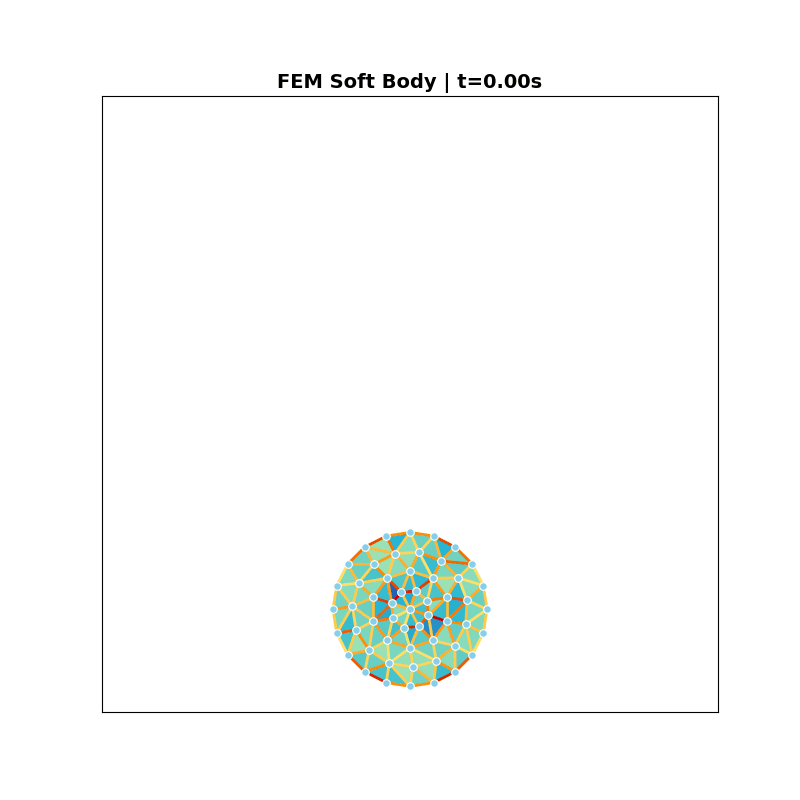

In [9]:
Image(filename='fem_simulation.gif')

---
## 5. Summary

**What we built:**
1. **FEM Force Kernel** - Computes internal forces from triangular elements using Neo-Hookean material model
2. **FEM Stiffness Matrix** - Assembles 9 blocks per triangle for the implicit solver
3. **Combined Solver** - Springs + FEM for both edge and area preservation

**Key Concepts:**
- **Deformation Gradient** $\mathbf{F} = \mathbf{D}_s \mathbf{D}_m^{-1}$ measures how the triangle deforms from rest
- **Neo-Hookean Energy** penalizes both stretch ($I_C$) and volume change ($J$)
- **Material Parameters:** Young's modulus $E$ and Poisson's ratio $\nu$ control stiffness and incompressibility

**Why FEM over Springs?**
- Springs only resist length changes along edges
- FEM resists **area/volume changes** - no more collapsing under compression!
- Combined spring+FEM gives both edge and area preservation

**Material Parameters Used:**
- Young's modulus: $E = 50.0$ (overall stiffness)
- Poisson's ratio: $\nu = 0.3$ (incompressibility)
- Derived: $\mu \approx 19.2$ (shear), $\lambda \approx 16.5$ (bulk)

**Next:** [04_reduction.ipynb](04_reduction.ipynb) - Accelerate simulation with Model Order Reduction!